---
Classical $\hat{q}$ with or without transverse components

In [1]:
import numpy as np

# hbar * c [GeV * fm]
hbarc = 0.197326 

# Simulation box 
L = 5.0
N = 1024
tau_sim = 0.3
DTS = 8

# Glasma fields
su_group = 'su3'
uv = 10.0
ir = 0.3
g2mu = 1.5

# Derived parameters
a = L/N
E0 = N / L * hbarc
DT = 1.0 / DTS
maxt = int(tau_sim / a * DTS)
nplus = maxt//DTS

g = 2         		
mu = g2mu / g**2

ns = 1      
nevents = 1

In [2]:
# Condition 1: 2*pi/L < m  (m ir regulator)
cond1_lhs = 2 * np.pi / L * hbarc
cond1 = cond1_lhs < ir
print(f"2π/L = {cond1_lhs:.4f} < m = {ir} {'passed' if cond1 else 'failed'}")

# Condition 2: m / g2mu < 1  (dense glasma)
cond2_lhs = ir / g2mu
cond2 = cond2_lhs < 1
print(f"m/g2mu = {cond2_lhs:.4f} < 1 {'passed' if cond2 else 'failed'}")

# Condition 3: g2mu * a < 1  (fine lattice)
cond3_lhs = g2mu * a / hbarc
cond3 = cond3_lhs < 1
print(f"g2mua = {cond3_lhs:.4f} < 1 {'passed' if cond3 else 'failed'}")

print(f"g2muL = {g2mu * L / hbarc :.4f}")

2π/L = 0.2480 < m = 0.3 passed
m/g2mu = 0.2000 < 1 passed
g2mua = 0.0371 < 1 passed
g2muL = 38.0082


In [3]:
import os

os.environ["MY_NUMBA_TARGET"] = "cuda"
os.environ["GAUGE_GROUP"] = su_group
os.environ["PRECISION"] = "double"

import warnings
from numba.core.errors import NumbaPerformanceWarning
warnings.filterwarnings('ignore', category=NumbaPerformanceWarning)

import sys
sys.path.append('..')

import curraun.core as core
import curraun.mv as mv
import curraun.initial as initial
initial.DEBUG = False

from curraun.numba_target import use_cuda, use_numba
if use_cuda:
    from numba import cuda

import pickle
from tqdm import tqdm

from curraun.qhat import TransportedForce
from curraun.qhat_correlators import LongTransportedForce, TransverseTransportedForce

/home2/carlos.lamas/condacurraun/lib/python3.10/site-packages/scipy/__init__.py:132: UserWarning: A NumPy version >=1.21.6 and <1.28.0 is required for this version of SciPy (detected version 1.21.5)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Using CUDA
Using SU(3)
Using double precision


In [4]:
def simulate_qhat(ev): 
    # Derived parameters
    a = L / N
    E0 = N / L * hbarc
    DT = 1.0 / DTS
    maxt = int(tau_sim / a * DTS)

    # Initialize Glasma fields
    mv.set_seed(314)
    s = core.Simulation(N, DT, g)
    va = mv.wilson(s, mu=mu / E0, m=ir / E0, uv=uv / E0, num_sheets=ns)
    vb = mv.wilson(s, mu=mu / E0, m=ir / E0, uv=uv / E0, num_sheets=ns)
    initial.init(s, va, vb)

    # Initialize the Qhat module
    qhat = TransportedForce(s, E0)
    qhat_long = LongTransportedForce(s)
    qhat_trans = TransverseTransportedForce(s)
    mom_broad, mom_broad_long, mom_broad_trans, tau =  [], [], [], []

    if use_cuda:
        qhat.copy_to_device()
        qhat_long.copy_to_device()
        qhat_trans.copy_to_device()

    with tqdm(total=maxt) as pbar:
        for t in range(maxt):
            # Compute momentum broadening from Qhat module
            if t % DTS == 0:
                if use_cuda:
                    qhat.copy_mean_to_host()
                    qhat_long.copy_mean_to_host()
                    qhat_trans.copy_mean_to_host()

                # Units GeV^2
                mom_broad.append(qhat.p_perp_mean * E0 ** 2)
                mom_broad_long.append(qhat_long.p_perp_mean * E0 ** 2)
                mom_broad_trans.append(qhat_trans.p_perp_mean * E0 ** 2)

                tau.append(t / DTS * a)
                
                if use_cuda:
                    qhat.copy_mean_to_device()
                    qhat_long.copy_mean_to_device()
                    qhat_trans.copy_mean_to_device()
            qhat.compute()
            qhat_long.compute()
            qhat_trans.compute()

            # Evolve Glasma fields
            core.evolve_leapfrog(s)

            pbar.set_description("Event " + str(ev+1))
            pbar.update(1)

    return mom_broad, mom_broad_long, mom_broad_trans, tau

In [ ]:
mom_broads, mom_broads_long, mom_broads_trans = [], [], []
for ev in range(nevents):
    mom_broad_ev, mom_broad_long_ev, mom_broad_trans_ev, tau = simulate_qhat(ev)
    mom_broads.append(mom_broad_ev)
    mom_broads_long.append(mom_broad_long_ev)
    mom_broads_trans.append(mom_broad_trans_ev)

tau = np.array(tau)
mom_broad = np.mean(mom_broads, axis=0)
mom_broad_long = np.mean(mom_broads_long, axis=0)
mom_broad_trans = np.mean(mom_broads_trans, axis=0)

Event 1:  14%|█▍        | 71/491 [00:39<02:57,  2.36it/s]

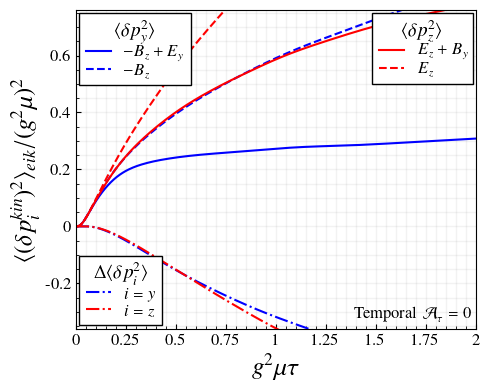

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import numpy as np

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{txfonts}"
})

fig, ax = plt.subplots(figsize=(5, 4))

colors = ['blue', 'red']

for i in [1, 2]:
    ax.plot(g2mu * tau, mom_broad[:, i] / g2mu**2, color=colors[i-1], linewidth=1.5, linestyle='-')
    ax.plot(g2mu * tau, mom_broad_long[:, i] / g2mu**2, color=colors[i-1], linewidth=1.5, linestyle='--')
    ax.plot(g2mu * tau, (mom_broad[:, i] - mom_broad_long[:, i]) / g2mu**2, color=colors[i-1], linewidth=1.5, linestyle='-.')

ax.set_xlim([0, 2])
ax.set_ylim([-0.36, 0.76])

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))

ax.set_xlabel(r"$g^2\mu\tau$", fontsize=18)
ax.set_ylabel(r"$\langle (\delta p_i^{kin})^2\rangle_{eik} / (g^2\mu)^2$", fontsize=18)
ax.grid(which='major', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
ax.minorticks_on()
ax.grid(which='minor', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='minor', direction='in')

legend1_elements = [
    Line2D([0], [0], color='blue', linestyle='-', lw=1.5, label=r'$-B_z+E_y$'),
    Line2D([0], [0], color='blue', linestyle='--', lw=1.5, label=r'$-B_z$'),
]
legend1 = ax.legend(handles=legend1_elements, fontsize=12, loc='upper left', handlelength=1.5,
    frameon=True, facecolor='white', edgecolor='black', framealpha=1.0,
    borderpad=0.1, labelspacing=0.1, title=r'$\langle \delta p^2_y\rangle$', title_fontsize=14)
legend1.get_frame().set_boxstyle("square")
ax.add_artist(legend1)

legend2_elements = [
    Line2D([0], [0], color='red', linestyle='-', lw=1.5, label=r'$E_z+B_y$'),
    Line2D([0], [0], color='red', linestyle='--', lw=1.5, label=r'$E_z$'),
]
legend2 = ax.legend(handles=legend2_elements, fontsize=12, loc='upper right',
                     handlelength=1.5, frameon=True, facecolor='white', edgecolor='black', framealpha=1.0,
                     borderpad=0.1, labelspacing=0.1, title=r'$\langle \delta p^2_z\rangle$', title_fontsize=14)
legend2.get_frame().set_boxstyle("square")
ax.add_artist(legend2)

legend3_elements = [
    Line2D([0], [0], color='blue', linestyle='-.', lw=1.5, label=r'$i=y$'),
    Line2D([0], [0], color='red', linestyle='-.', lw=1.5, label=r'$i=z$'),
]
legend3 = ax.legend(handles=legend3_elements, fontsize=12, loc='lower left', handlelength=1.5,
    frameon=True, facecolor='white', edgecolor='black', framealpha=1.0,
    borderpad=0.1, labelspacing=0.1, title=r'$\Delta \langle \delta p^2_i\rangle$', title_fontsize=14)
legend3.get_frame().set_boxstyle("square")

ax.text(0.99, 0.02, r'$\mathrm{Temporal}\,\,\mathcal{A}_\tau=0$', transform=ax.transAxes, fontsize=12, ha='right', va='bottom', bbox=dict(boxstyle='square', facecolor='white', edgecolor='black', alpha=0.0, pad=0.2))

plt.tight_layout()
plt.savefig('mom_broad_eb_contrib.pdf', facecolor='w')
plt.show()

/tmp/ipykernel_12076/1769682907.py:17: RuntimeWarning: invalid value encountered in true_divide
  ratio = (mom_broad[:, i] - mom_broad_long[:, i]) / mom_broad[:, i]


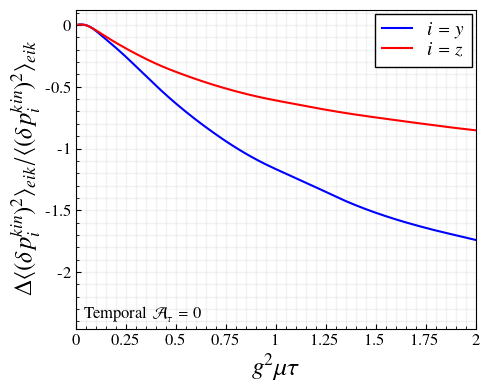

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import numpy as np

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{txfonts}"
})

fig, ax = plt.subplots(figsize=(5, 4))

colors = ['blue', 'red']

for i in [1, 2]:
    ratio = (mom_broad[:, i] - mom_broad_long[:, i]) / mom_broad[:, i]
    ax.plot(g2mu * tau, ratio, color=colors[i-1], linewidth=1.5, linestyle='-')

# ax.axhline(1, color='gray', linestyle='--', linewidth=1.5)

ax.set_xlim([0, 2])
# ax.set_ylim([0, 1.05])

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))

ax.set_xlabel(r"$g^2\mu\tau$", fontsize=18)
ax.set_ylabel(r"$\Delta \langle (\delta p_i^{kin})^2\rangle_{eik} / \langle (\delta p_i^{kin})^2\rangle_{eik}$", fontsize=18)
ax.grid(which='major', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
ax.minorticks_on()
ax.grid(which='minor', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='minor', direction='in')

legend_elements = [
    Line2D([0], [0], color='blue', linestyle='-', lw=1.5, label=r'$i=y$'),
    Line2D([0], [0], color='red', linestyle='-', lw=1.5, label=r'$i=z$'),
]
legend = ax.legend(handles=legend_elements, fontsize=14, loc='upper right', handlelength=1.5,
                    frameon=True, facecolor='white', edgecolor='black', framealpha=1.0,
                    borderpad=0.1, labelspacing=0.1)
legend.get_frame().set_boxstyle("square")

ax.text(0.02, 0.02, r'$\mathrm{Temporal}\,\,\mathcal{A}_\tau=0$', transform=ax.transAxes, fontsize=12, ha='left', va='bottom', bbox=dict(boxstyle='square', facecolor='white', edgecolor='black', alpha=0.0, pad=0.2))

plt.tight_layout()
plt.savefig('mom_broad_long_fraction.pdf', facecolor='w')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import numpy as np

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{txfonts}"
})

fig, ax = plt.subplots(figsize=(5, 4))

colors = ['blue', 'red']

for i in [1, 2]:
    ax.plot(g2mu * tau, mom_broad[:, i] / g2mu**2, color=colors[i-1], linewidth=1.5, linestyle='-')
    ax.plot(g2mu * tau, mom_broad_long[:, i] / g2mu**2, color=colors[i-1], linewidth=1.5, linestyle='--')
    ax.plot(g2mu * tau, mom_broad_trans[:, i] / g2mu**2, color=colors[i-1], linewidth=1.5, linestyle='-.')

ax.set_xlim([0, 2])
ax.set_ylim([0, 2])

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))

ax.set_xlabel(r"$g^2\mu\tau$", fontsize=18)
ax.set_ylabel(r"$\langle (\delta p_i^{kin})^2\rangle_{eik} / (g^2\mu)^2$", fontsize=18)
ax.grid(which='major', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
ax.minorticks_on()
ax.grid(which='minor', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='minor', direction='in')

legend1_elements = [
    Line2D([0], [0], color='blue', linestyle='-', lw=1.5, label=r'$-B_z+E_y$'),
    Line2D([0], [0], color='blue', linestyle='--', lw=1.5, label=r'$-B_z$'),
    Line2D([0], [0], color='blue', linestyle='-.', lw=1.5, label=r'$E_y$'),
]
legend1 = ax.legend(handles=legend1_elements, fontsize=12, loc='upper left', handlelength=1.5,
    frameon=True, facecolor='white', edgecolor='black', framealpha=1.0,
    borderpad=0.1, labelspacing=0.1, title=r'$\langle \delta p^2_y\rangle$', title_fontsize=14)
legend1.get_frame().set_boxstyle("square")
ax.add_artist(legend1)

legend2_elements = [
    Line2D([0], [0], color='red', linestyle='-', lw=1.5, label=r'$E_z+B_y$'),
    Line2D([0], [0], color='red', linestyle='--', lw=1.5, label=r'$E_z$'),
    Line2D([0], [0], color='red', linestyle='-.', lw=1.5, label=r'$B_y$'),
]
legend2 = ax.legend(handles=legend2_elements, fontsize=12, loc='upper right',
    handlelength=1.5, frameon=True, facecolor='white', edgecolor='black', framealpha=1.0,
    borderpad=0.1, labelspacing=0.1, title=r'$\langle \delta p^2_z\rangle$', title_fontsize=14)
legend2.get_frame().set_boxstyle("square")

ax.text(0.99, 0.02, r'$\mathrm{Temporal}\,\,\mathcal{A}_\tau=0$', transform=ax.transAxes, fontsize=12, ha='right', va='bottom', bbox=dict(boxstyle='square', facecolor='white', edgecolor='black', alpha=0.0, pad=0.2))

plt.tight_layout()
plt.savefig('mom_broad_eb_long_trans.pdf', facecolor='w')
plt.show()

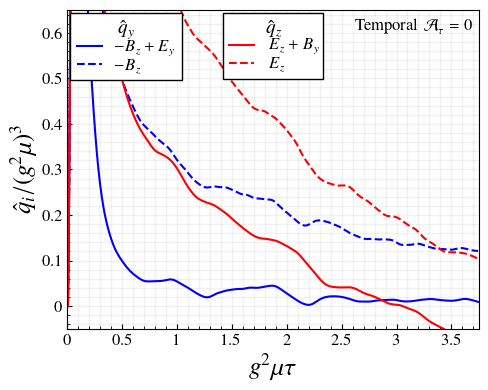

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import numpy as np

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{txfonts}"
})

fig, ax = plt.subplots(figsize=(5, 4))

colors = ['blue', 'red']

for i in [1, 2]:
    qhat_deriv = np.diff(mom_broad[:, i]) / np.diff(tau)
    ax.plot(g2mu * tau[1:], qhat_deriv / g2mu**3, color=colors[i-1], linewidth=1.5, linestyle='-')

    qhat_long_deriv = np.diff(mom_broad_long[:, i]) / np.diff(tau)
    ax.plot(g2mu * tau[1:], qhat_long_deriv / g2mu**3, color=colors[i-1], linewidth=1.5, linestyle='--')

ax.set_xlim([0, g2mu * tau_sim])
ax.set_ylim([-0.05, 0.65])

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))

ax.set_xlabel(r"$g^2\mu\tau$", fontsize=18)
ax.set_ylabel(r"$\hat{q}_i / (g^2\mu)^3$", fontsize=18)
ax.grid(which='major', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
ax.minorticks_on()
ax.grid(which='minor', color='gray', linestyle='-', linewidth=1, alpha=0.1)
ax.tick_params(axis='both', which='minor', direction='in')

legend1_elements = [
    Line2D([0], [0], color='blue', linestyle='-', lw=1.5, label=r'$-B_z+E_y$'),
    Line2D([0], [0], color='blue', linestyle='--', lw=1.5, label=r'$-B_z$'),
]
legend1 = ax.legend(handles=legend1_elements, fontsize=12, loc='upper left', handlelength=1.5,
                     frameon=True, facecolor='white', edgecolor='black', framealpha=1.0,
                     borderpad=0.1, labelspacing=0.1, title=r'$\hat{q}_y$', title_fontsize=14)
legend1.get_frame().set_boxstyle("square")
ax.add_artist(legend1)

legend2_elements = [
    Line2D([0], [0], color='red', linestyle='-', lw=1.5, label=r'$E_z+B_y$'),
    Line2D([0], [0], color='red', linestyle='--', lw=1.5, label=r'$E_z$'),
]
legend2 = ax.legend(handles=legend2_elements, fontsize=12, loc='upper center', handlelength=1.5,
                     frameon=True, facecolor='white', edgecolor='black', framealpha=1.0,
                     borderpad=0.1, labelspacing=0.1, title=r'$\hat{q}_z$', title_fontsize=14)
legend2.get_frame().set_boxstyle("square")

ax.text(0.7, 0.97, r'$\mathrm{Temporal}\,\,\mathcal{A}_\tau=0$', transform=ax.transAxes, fontsize=12, ha='left', va='top', bbox=dict(boxstyle='square', facecolor='white', edgecolor='black', alpha=0.0, pad=0.2))

plt.tight_layout()
plt.savefig('qhat_eb_contrib.pdf', facecolor='w')
plt.show()